In [1]:
from pathlib import Path
import importlib
import functions
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
importlib.reload(functions)
from tqdm.notebook import tqdm
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score, accuracy_score
)
import shap
import matplotlib.pyplot as plt
import seaborn as sns

functions.set_seed(1905)

In [5]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "datasets/XGBoost"
OUTPUT_FIG = PROJECT_ROOT / "figures/XGBoost"
OUTPUT_IMP = PROJECT_ROOT / "datasets/FeatureImp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_IMP.mkdir(parents=True, exist_ok=True)

In [6]:
aap_symbols = pd.read_csv(PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv', index_col=0).index
aap_symbols

Index(['CYSLTR1', 'PRXL2B', 'PTGS2', 'PTGER4', 'PNPLA8', 'LIPA', 'PTGER2',
       'LTB4R', 'ABCC1', 'CYSLTR2',
       ...
       'GPX7', 'PLA2G4A', 'EPHX2', 'ACOT11', 'ABCC6', 'MGST3', 'ACSL4',
       'CYP4F3', 'ALOX15B', 'LTA4H'],
      dtype='object', length=103)

In [7]:
#whole dataset
dataset = functions.GeneExpressionDataset(
    exp_matrix_path= PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv',
    conf_matrix_path= PROJECT_ROOT / 'datasets/adj_giant.csv',
    threshold=0.1
)

k = 10
n = 9
split_seed = 1905
y = np.array([data.y.item() for data in dataset])
country = np.array(dataset.country)
strat = np.array([f"{label}__{group}" for label, group in zip(y, country)])
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=split_seed)

k = 10
split_seed = 1905
strat = np.array([f"{label}__{group}" for label, group in zip(y, country)])
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=1905)

In [9]:
from xgboost import XGBClassifier

H = functions.sample_hyperparams(model_type="XGBoost", n=n, seed=2026)
t_scores = []

D = np.array([data.y.item() for data in dataset])
folds: [np.ndarray] = []
for _, fold_idx in skf.split(np.zeros(len(D)), strat):
    folds.append(fold_idx)

all_y_true = []
all_y_pred = []
cms = []

shap_values_test_folds = []
expected_values = []
X_test_list = []
X_unscaled_test_list = []
all_probas = []
logits = []

metrics_u_j = {
    "Accuracy": pd.DataFrame(columns=range(k)),
    "F1": pd.DataFrame(columns=range(k)),
    "Precision": pd.DataFrame(columns=range(k)),
    "Recall": pd.DataFrame(columns=range(k)),
    "AUC-PRC": pd.DataFrame(columns=range(k)),
    "AUC-ROC": pd.DataFrame(columns=range(k))
}
metrics_t = {
    "Accuracy": np.array([]),
    "F1": np.array([]),
    "Precision": np.array([]),
    "Recall": np.array([]),
    "AUC-PRC": np.array([]),
    "AUC-ROC": np.array([])
}

#Progress bar
total = k*n*(k-1)
pbar = tqdm(total=total, desc="Verarbeitung läuft")

for i in range(k):
    test_idx = folds[i]
    # Indices for "I - {i}"
    other_fold_ids = [m for m in range(k) if m != i]
    # Dictionary for fold scores per metric
    # --------- AHP0 loop over hyperparams (j in J) ----------
    best_j = None
    best_ubar = -math.inf

    best_iterations_inner = []
    for j, h_j in enumerate(H):
        u_vals = {m: [] for m in metrics_u_j.keys()}

        # ------ cross-validation loop over validation folds m in I\{i} ------
        for m in other_fold_ids:
            val_idx = folds[m]
            train_fold_ids = [r for r in range(k) if r not in (i, m)]
            train_idx = np.concatenate([folds[r] for r in train_fold_ids], axis=0)

            pd.DataFrame(train_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{m}_train.csv", index=False)
            pd.DataFrame(val_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{m}_val.csv", index=False)
            functions.removeBatchEffect(OUTPUT_DIR / f"fold_{m}_train.csv",
                      OUTPUT_DIR / f"fold_{m}_val.csv",
                      str(m), "XGBoost")

            train_dataset = functions.GeneExpressionDataset(
                exp_matrix_path= OUTPUT_DIR / f"train_corrected_{m}.csv",
                conf_matrix_path= PROJECT_ROOT / "datasets"/ "adj_giant.csv",
                threshold=0.1
            )
            val_dataset = functions.GeneExpressionDataset(
                exp_matrix_path= OUTPUT_DIR / f"val_corrected_{m}.csv",
                conf_matrix_path= PROJECT_ROOT / "datasets" / "adj_giant.csv",
                threshold=0.1
            )

            scaler = StandardScaler()
            scaler.fit(train_dataset.expr)
            
            X_train = scaler.transform(train_dataset.expr)
            y_train = train_dataset.labels
            X_val = scaler.transform(val_dataset.expr)
            y_val = val_dataset.labels

            n_males = np.sum(y_train == 1)
            n_females = np.sum(y_train == 0)
            spw = n_females / n_males
                        
            xgb = XGBClassifier(
                n_estimators=800,
                sampling_method = "uniform",
                learning_rate=h_j["eta"],
                max_depth=h_j["max_depth"],
                subsample=h_j["subsample"],
                min_child_weight=h_j["min_child_weight"],
                #colsample_bytree=h_j["colsample_bytree"],
                reg_lambda=h_j["lambda"],
                objective="binary:logistic",
                #eval_metric="auc",
                #early_stopping_rounds=10, 
                tree_method="hist",
                scale_pos_weight = spw,
                n_jobs=-1,
                random_state=2026,
            )
            #xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)],verbose=False)
            xgb.fit(X_train, y_train)
            y_prob = xgb.predict_proba(X_val)[:, 1]
            y_pred = xgb.predict(X_val)
            #y_pred = (y_prob >= 0.5).astype(int)
            #best_iterations_inner.append(xgb.best_iteration)
            
            u_vals['Precision'].append(precision_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Recall'].append(recall_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Accuracy'].append(accuracy_score(y_val, y_pred))
            u_vals['F1'].append(f1_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['AUC-PRC'].append(average_precision_score(y_val, y_prob))
            u_vals['AUC-ROC'].append(roc_auc_score(y_val, y_prob))
            pbar.update(1)

        ubar_j = float(np.mean(u_vals["Recall"]))
        for metric in metrics_u_j.keys():
            mean = np.mean(u_vals[metric])
            std = np.std(u_vals[metric])
            metrics_u_j[metric].loc[j, i] = f"{mean:.3f} ± {std:.3f}" 

        if ubar_j > best_ubar:
            best_ubar = ubar_j
            best_j = j

    assert best_j is not None
    h_star = H[best_j]
    
    train_idx_full = np.concatenate([folds[r] for r in range(k) if r != i], axis=0)

    pd.DataFrame(train_idx_full, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{i}_train_full.csv", index=False)
    pd.DataFrame(test_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{i}_test.csv", index=False)
    functions.removeBatchEffect(OUTPUT_DIR / f"fold_{i}_train_full.csv",
                      OUTPUT_DIR / f"fold_{i}_test.csv",
                      str(i), "XGBoost")

    train_dataset = functions.GeneExpressionDataset(
        exp_matrix_path= OUTPUT_DIR / f"train_corrected_{i}.csv",
        conf_matrix_path= PROJECT_ROOT / "datasets" / 'adj_giant.csv',
        threshold=0.1
    )
    test_dataset = functions.GeneExpressionDataset(
        exp_matrix_path= OUTPUT_DIR / f"test_corrected_{i}.csv",
        conf_matrix_path=PROJECT_ROOT / "datasets" / 'adj_giant.csv',
        threshold=0.1
    )

    scaler = StandardScaler()
    #calculate mean and sd on training data
    scaler.fit(train_dataset.expr)

    X_train = scaler.transform(train_dataset.expr)
    y_train = train_dataset.labels
    X_test = scaler.transform(test_dataset.expr)
    y_test = test_dataset.labels

    n_males = np.sum(y_train == 1)
    n_females = np.sum(y_train == 0)
    spw = n_females / n_males

    #n_estimators_final = int(np.max(best_iterations_inner))
    xgb = XGBClassifier(
                n_estimators=800,
                sampling_method = "uniform",
                learning_rate=h_star["eta"],
                max_depth=h_star["max_depth"],
                subsample=h_star["subsample"],
                #colsample_bytree=h_star["colsample_bytree"],
                min_child_weight=h_star["min_child_weight"],
                scale_pos_weight = spw,
                reg_lambda=h_star["lambda"],
                objective="binary:logistic",
                #eval_metric="auc",
                #early_stopping_rounds=10,
                tree_method="hist",
                n_jobs=-1,
                random_state=2026,
            )
    xgb.fit(X_train, y_train)
    y_prob = xgb.predict_proba(X_test)[:, 1]
    y_pred = xgb.predict(X_test)
    #y_pred = (y_prob >= 0.5).astype(int)
    logits.append(xgb.predict(X_test, output_margin=True))

    metrics_t['Precision'] = np.append(metrics_t['Precision'], precision_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Recall'] = np.append(metrics_t['Recall'], recall_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Accuracy'] = np.append(metrics_t['Accuracy'], accuracy_score(y_test, y_pred))
    metrics_t['F1'] = np.append(metrics_t['F1'], f1_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['AUC-PRC'] = np.append(metrics_t['AUC-PRC'], average_precision_score(y_test, y_prob))
    metrics_t['AUC-ROC'] = np.append(metrics_t['AUC-ROC'], roc_auc_score(y_test, y_prob))

    X_test_list.append(X_test)
    X_unscaled_test_list.append(test_dataset.expr)

    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test)
    shap_values_test_folds.append(shap_values)
    all_probas.append(y_prob)
    expected_values.extend([explainer.expected_value] * len(X_test))

    t_scores.append(accuracy_score(y_test, y_pred))
    all_y_true.append(y_test)
    all_y_pred.append(y_pred)
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    cms.append(cm)
pbar.close()
    
mean = float(np.mean(t_scores))
std = float(np.std(t_scores, ddof=1))
print(mean, std)

Verarbeitung läuft:   0%|          | 0/810 [00:00<?, ?it/s]

0.6761904761904761 0.025093260980535628


In [10]:
H

[{'model': 'XGBoost',
  'eta': 0.07,
  'max_depth': 3,
  'subsample': 0.6,
  'min_child_weight': 4,
  'colsample_bytree': 0.2,
  'lambda': 1.0},
 {'model': 'XGBoost',
  'eta': 0.01,
  'max_depth': 4,
  'subsample': 0.8,
  'min_child_weight': 2,
  'colsample_bytree': 0.5,
  'lambda': 5.0},
 {'model': 'XGBoost',
  'eta': 0.05,
  'max_depth': 6,
  'subsample': 1.0,
  'min_child_weight': 1,
  'colsample_bytree': 0.5,
  'lambda': 2.0},
 {'model': 'XGBoost',
  'eta': 0.01,
  'max_depth': 4,
  'subsample': 0.6,
  'min_child_weight': 6,
  'colsample_bytree': 0.3,
  'lambda': 5.0},
 {'model': 'XGBoost',
  'eta': 0.03,
  'max_depth': 5,
  'subsample': 0.8,
  'min_child_weight': 6,
  'colsample_bytree': 0.1,
  'lambda': 2.0},
 {'model': 'XGBoost',
  'eta': 0.05,
  'max_depth': 6,
  'subsample': 0.8,
  'min_child_weight': 2,
  'colsample_bytree': 0.2,
  'lambda': 1.0},
 {'model': 'XGBoost',
  'eta': 0.01,
  'max_depth': 4,
  'subsample': 0.6,
  'min_child_weight': 1,
  'colsample_bytree': 0.5,
  '

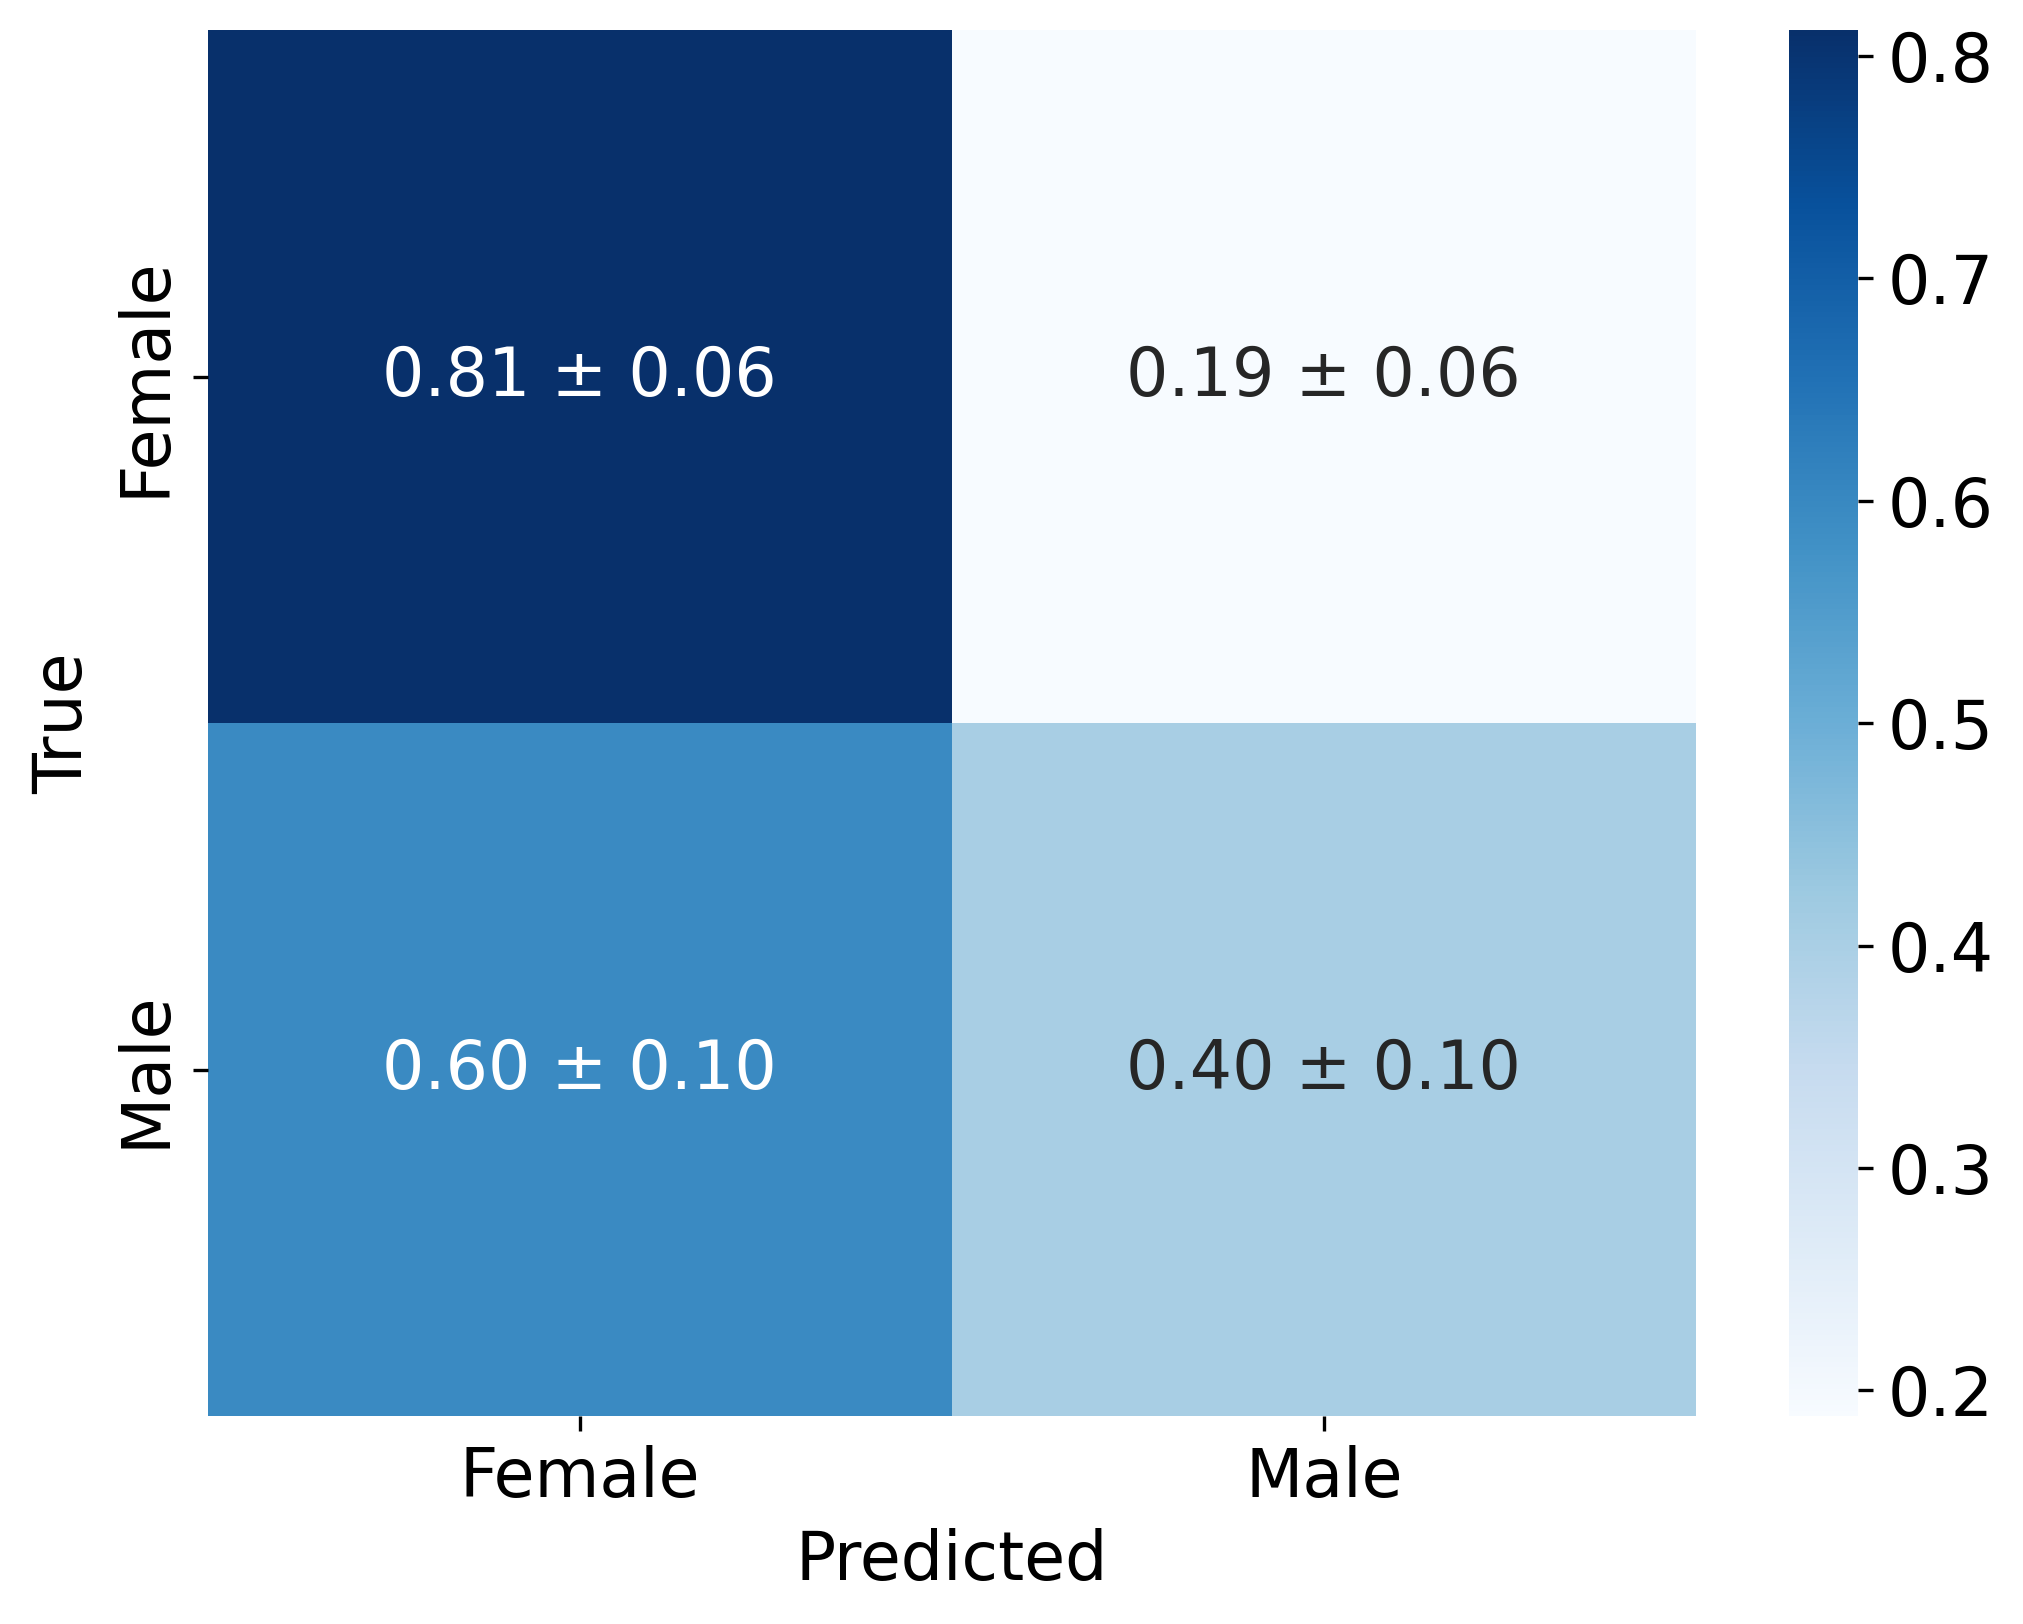

In [11]:
cms = np.array(cms)

cm_mean = np.mean(cms, axis=0)
cm_std  = np.std(cms, axis=0)

plt.figure(figsize=(8, 6), dpi=300)
labels = np.array([
    [f"{m:.2f} ± {s:.2f}" for m, s in zip(row_m, row_s)]
    for row_m, row_s in zip(cm_mean, cm_std)
])

labels_names = ["Female", "Male"]
ax = sns.heatmap(cm_mean, annot=labels, fmt="", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names, annot_kws={"size": 16})
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel("Predicted", fontsize=16)
ax.set_ylabel("True", fontsize=16)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.savefig(OUTPUT_FIG / "confusion_matrix_xgb.pdf", bbox_inches="tight")
plt.show()

In [12]:
metrics_t

{'Accuracy': array([0.69047619, 0.69047619, 0.66666667, 0.71428571, 0.68292683,
        0.63414634, 0.68292683, 0.68292683, 0.63414634, 0.68292683]),
 'F1': array([0.58730159, 0.55789474, 0.63703704, 0.66578249, 0.60722181,
        0.58585859, 0.64107744, 0.60722181, 0.5467944 , 0.64107744]),
 'Precision': array([0.64285714, 0.65135135, 0.63703704, 0.68914956, 0.63715278,
        0.58791209, 0.65373563, 0.61060606, 0.54848485, 0.63888889]),
 'Recall': array([0.58928571, 0.57142857, 0.63703704, 0.65925926, 0.60449735,
        0.58465608, 0.63717949, 0.60488506, 0.54597701, 0.64423077]),
 'AUC-PRC': array([0.53800936, 0.4790127 , 0.49992476, 0.59659208, 0.57979574,
        0.49116156, 0.64332824, 0.41285545, 0.44784575, 0.55066982]),
 'AUC-ROC': array([0.70408163, 0.56632653, 0.67901235, 0.64444444, 0.77248677,
        0.66402116, 0.74615385, 0.5862069 , 0.52873563, 0.66483516])}

In [13]:
metrics_u_j

{'Accuracy':                0              1              2              3              4  \
 0  0.667 ± 0.040  0.658 ± 0.047  0.653 ± 0.040  0.648 ± 0.064  0.654 ± 0.047   
 1  0.637 ± 0.031  0.677 ± 0.048  0.656 ± 0.037  0.661 ± 0.041  0.673 ± 0.045   
 2  0.656 ± 0.042  0.656 ± 0.053  0.629 ± 0.072  0.656 ± 0.044  0.644 ± 0.037   
 3  0.661 ± 0.048  0.688 ± 0.037  0.659 ± 0.046  0.659 ± 0.034  0.649 ± 0.054   
 4  0.669 ± 0.039  0.680 ± 0.029  0.648 ± 0.051  0.669 ± 0.031  0.649 ± 0.038   
 5  0.677 ± 0.046  0.666 ± 0.051  0.653 ± 0.039  0.661 ± 0.027  0.649 ± 0.040   
 6  0.659 ± 0.047  0.693 ± 0.065  0.672 ± 0.037  0.672 ± 0.043  0.676 ± 0.023   
 7  0.666 ± 0.034  0.696 ± 0.042  0.664 ± 0.041  0.669 ± 0.039  0.665 ± 0.047   
 8  0.642 ± 0.046  0.653 ± 0.057  0.632 ± 0.075  0.661 ± 0.026  0.646 ± 0.049   
 
                5              6              7              8              9  
 0  0.660 ± 0.029  0.619 ± 0.066  0.649 ± 0.048  0.692 ± 0.059  0.662 ± 0.051  
 1  0.686 ± 0.05

C:\Users\fabia\AppData\Local\Temp\ipykernel_52320\2356560625.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_all,X_test_all,plot_type="bar",feature_names=aap_symbols,show=False, max_display=20)


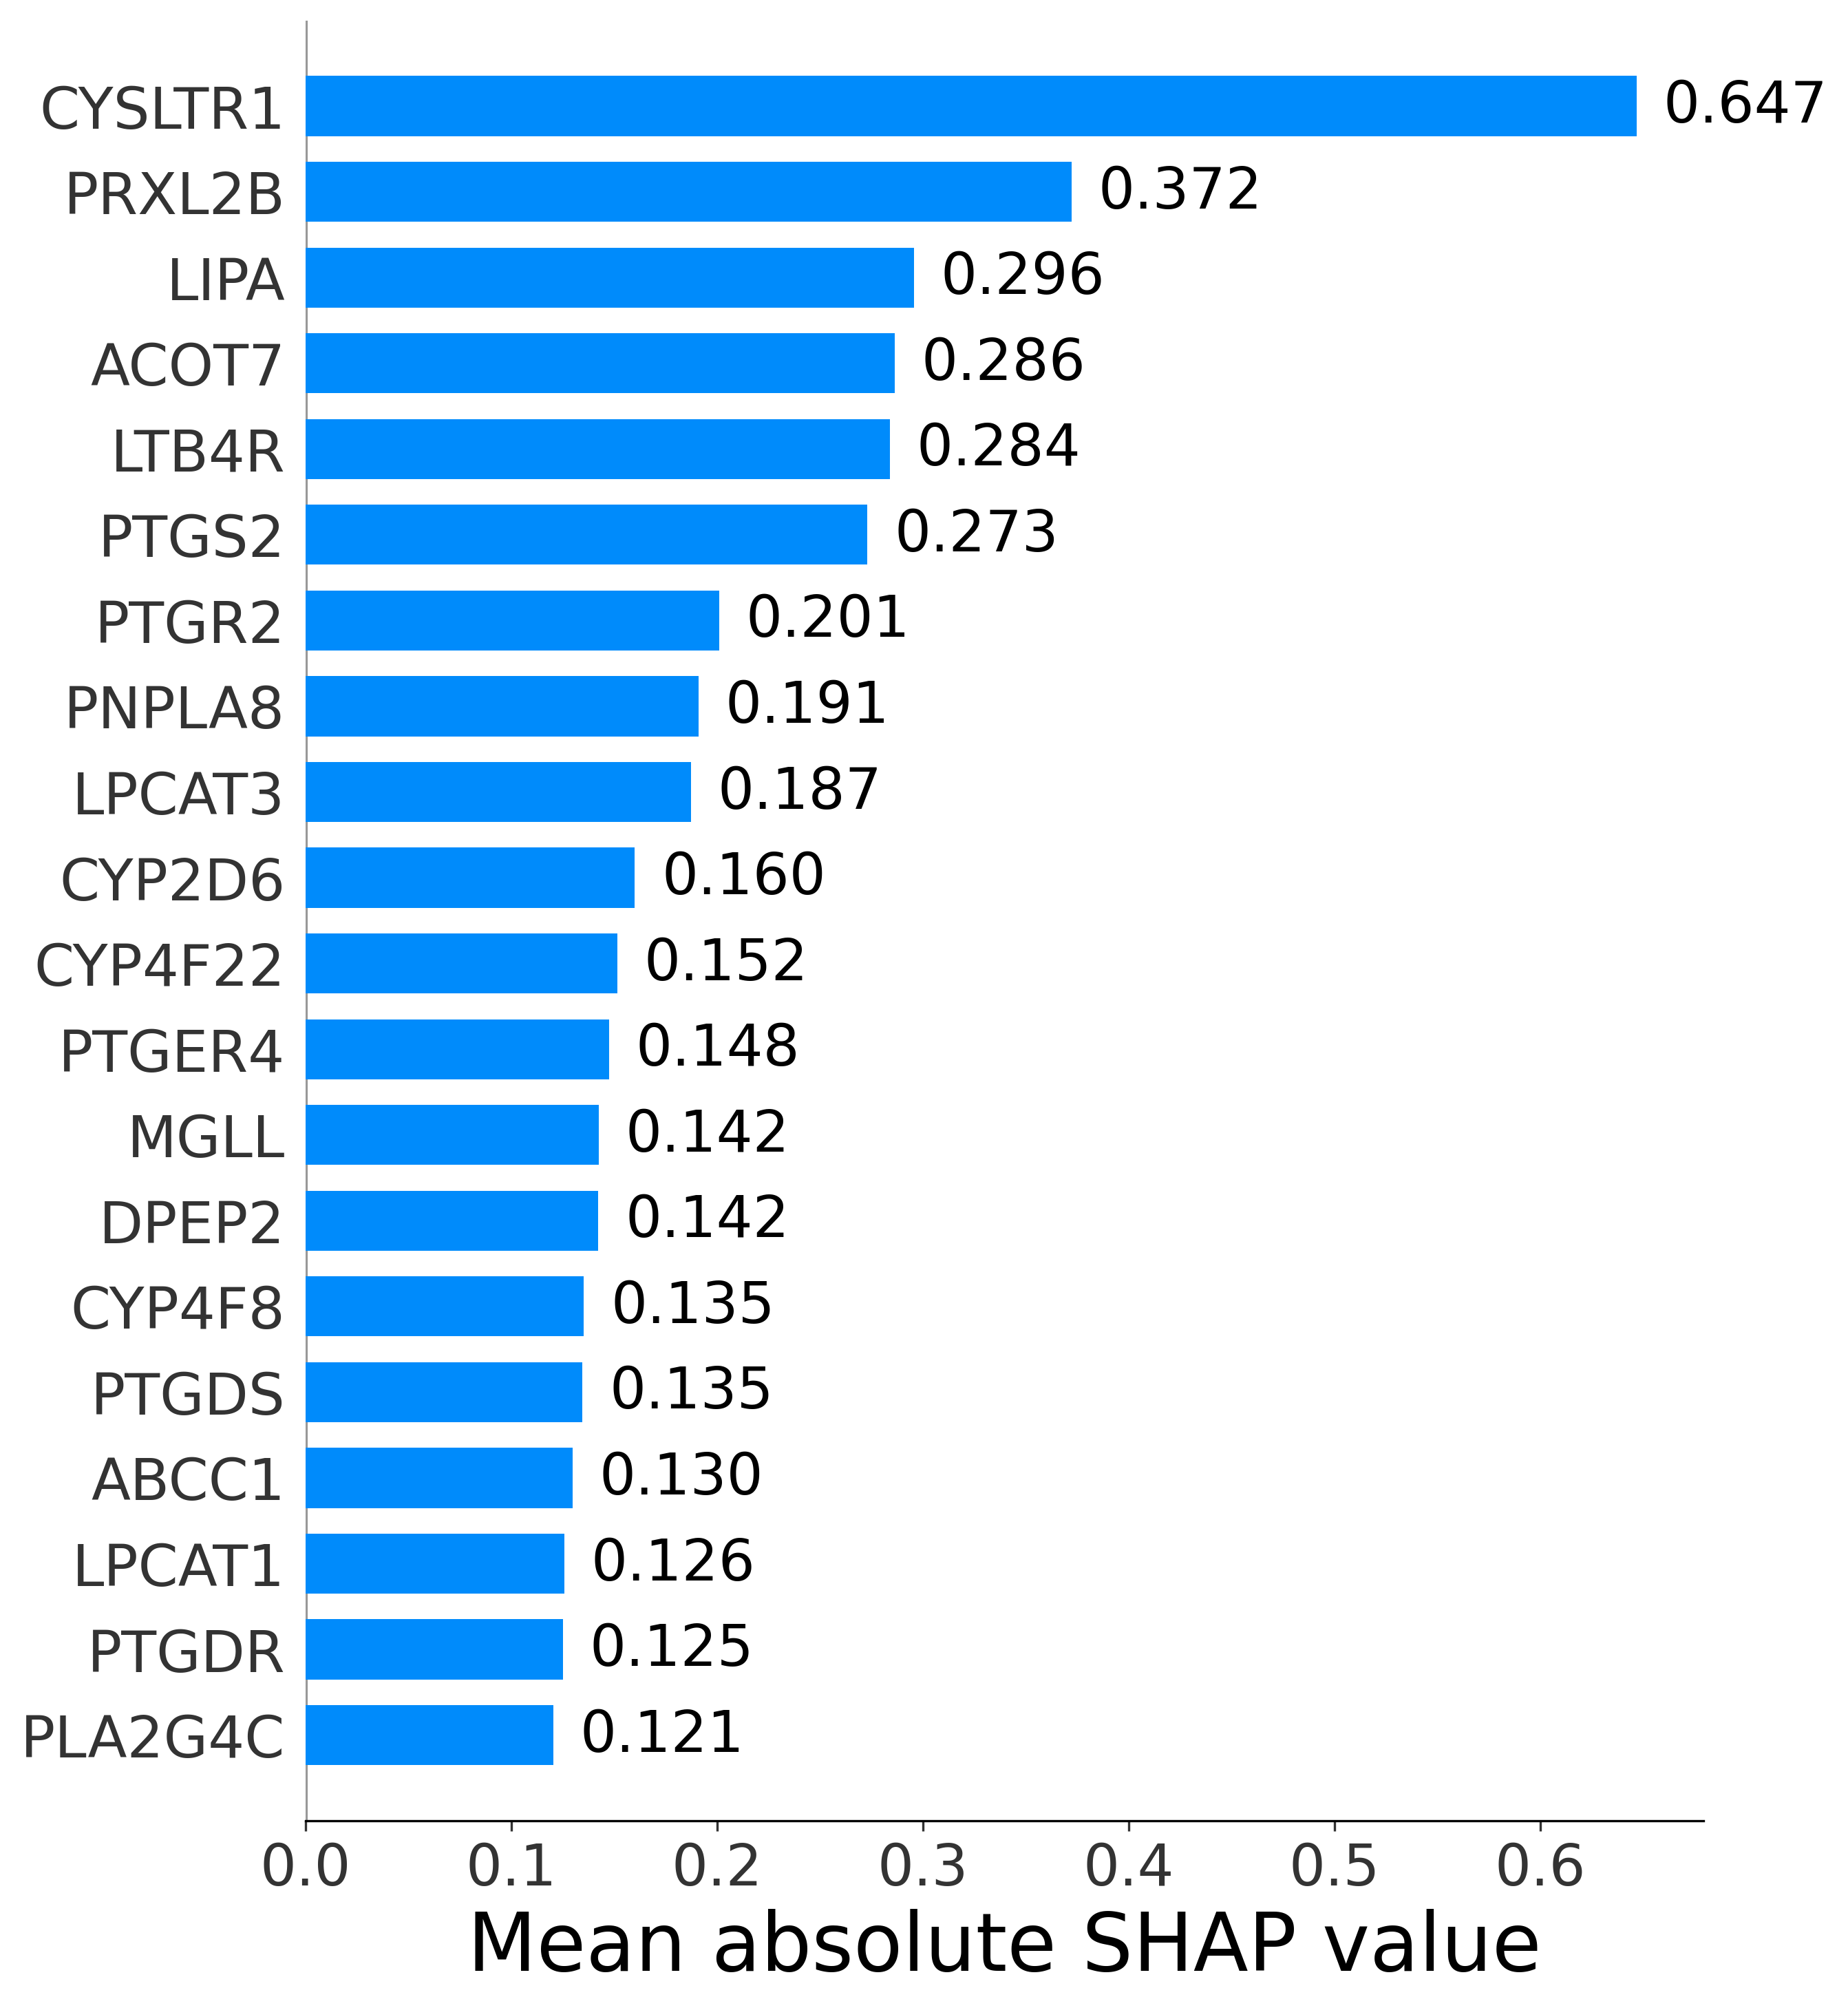

In [14]:
import shap
X_test_all = np.vstack(X_test_list)
X_unscaled_test_all = np.vstack(X_unscaled_test_list)
shap_all = np.vstack(shap_values_test_folds)
shap_all = shap_all


importance = np.mean(np.abs(shap_all), axis=0)
top_idx = np.argsort(importance)[::-1][:20]

pd.DataFrame({"Symbols": aap_symbols[np.argsort(importance)[::-1]], "XGBoostImp": importance[np.argsort(importance)[::-1]]}).to_csv(OUTPUT_IMP / "xgboostimp.csv", index=False, sep=";")

shap_top = shap_all[:, top_idx]
X_top = X_test_all[:, top_idx]
importance_top = importance[top_idx]

fig = plt.figure(figsize=(12, 6),dpi=300)
shap.summary_plot(shap_all,X_test_all,plot_type="bar",feature_names=aap_symbols,show=False, max_display=20)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("Mean absolute SHAP value", fontsize=28)
offset = max(importance_top) * 0.02

for i, v in enumerate(importance_top[::-1]):
    ax.text(v + offset, i, f"{v:.3f}", va='center', fontsize=20)

plt.xlabel("Mean absolute SHAP value")
fig.savefig(OUTPUT_FIG / "shap_summary_xgb_bar.pdf", bbox_inches="tight")
plt.show()
plt.close()

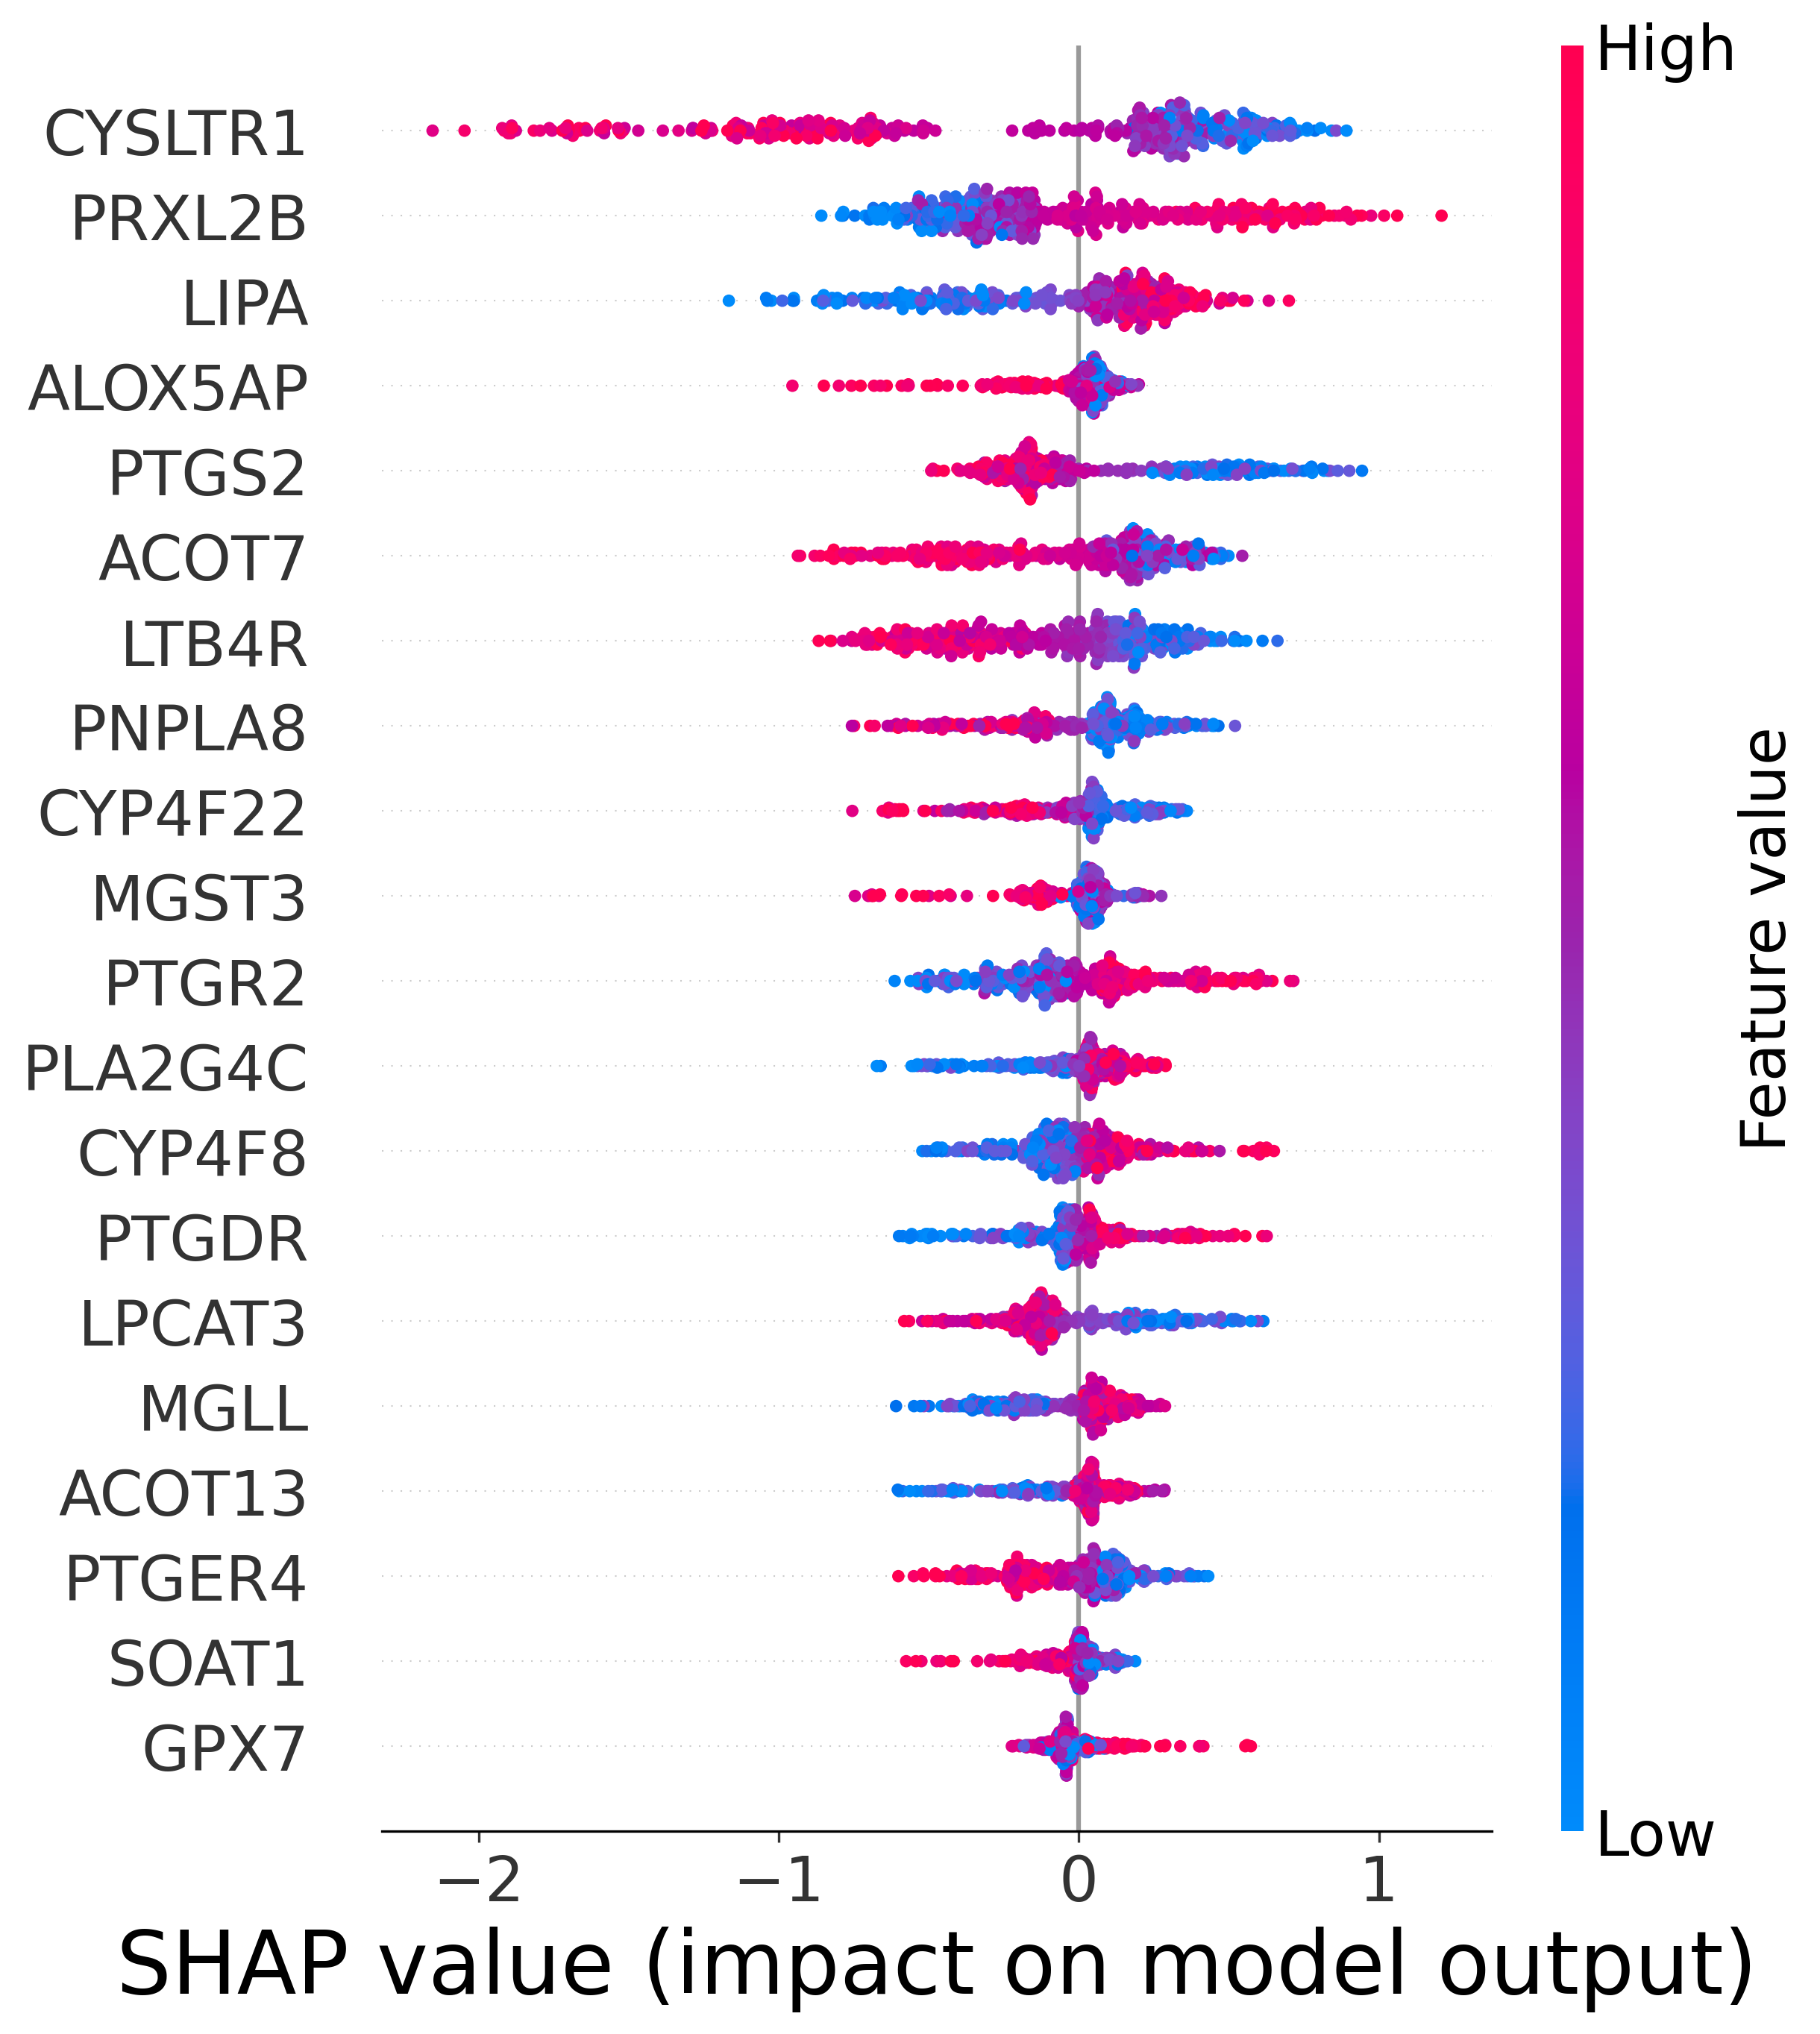

In [15]:
importance = np.max(np.abs(shap_all), axis=0)
order = np.argsort(importance)[::-1]

explanation = shap.Explanation(
    values=shap_all,
    data=X_test_all,
    feature_names=aap_symbols,
    base_values=expected_values
)
explanation.data = X_unscaled_test_all

fig = plt.figure(figsize=(12, 6), dpi=300)
shap.plots.beeswarm(explanation, max_display=20, show=False, order=order, group_remaining_features=False)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=28)
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=20)
cbar.set_ylabel("Feature value", fontsize=20)
plt.subplots_adjust(top=0.95)
fig.savefig(OUTPUT_FIG / "shap_summary_xgb.pdf", bbox_inches="tight")
plt.show()
plt.close()

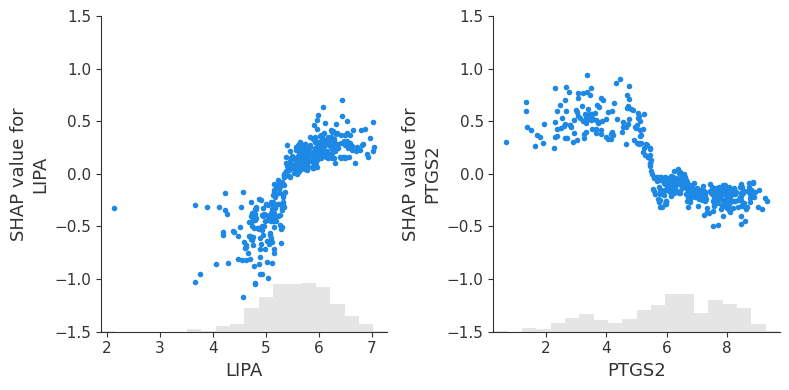

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

#shap.plots.scatter(
#    explanation[:, "CYSLTR1"],
#    ax=axes[0],
#    show=False,
#)
shap.plots.scatter(
    explanation[:, "LIPA"],
    ax=axes[0],
    show=False,
)
shap.plots.scatter(
    explanation[:, "PTGS2"],
    ax=axes[1],
    show=False
)
#shap.plots.scatter(
#    explanation[:, "ACOT7"],
#    ax=axes[3],
#    show=False
#)

for ax in axes:
    ax.set_ylim(-1.5, 1.5)
    
plt.tight_layout()
fig.savefig(OUTPUT_FIG / "scatter_plots.pdf", bbox_inches="tight")
plt.show()

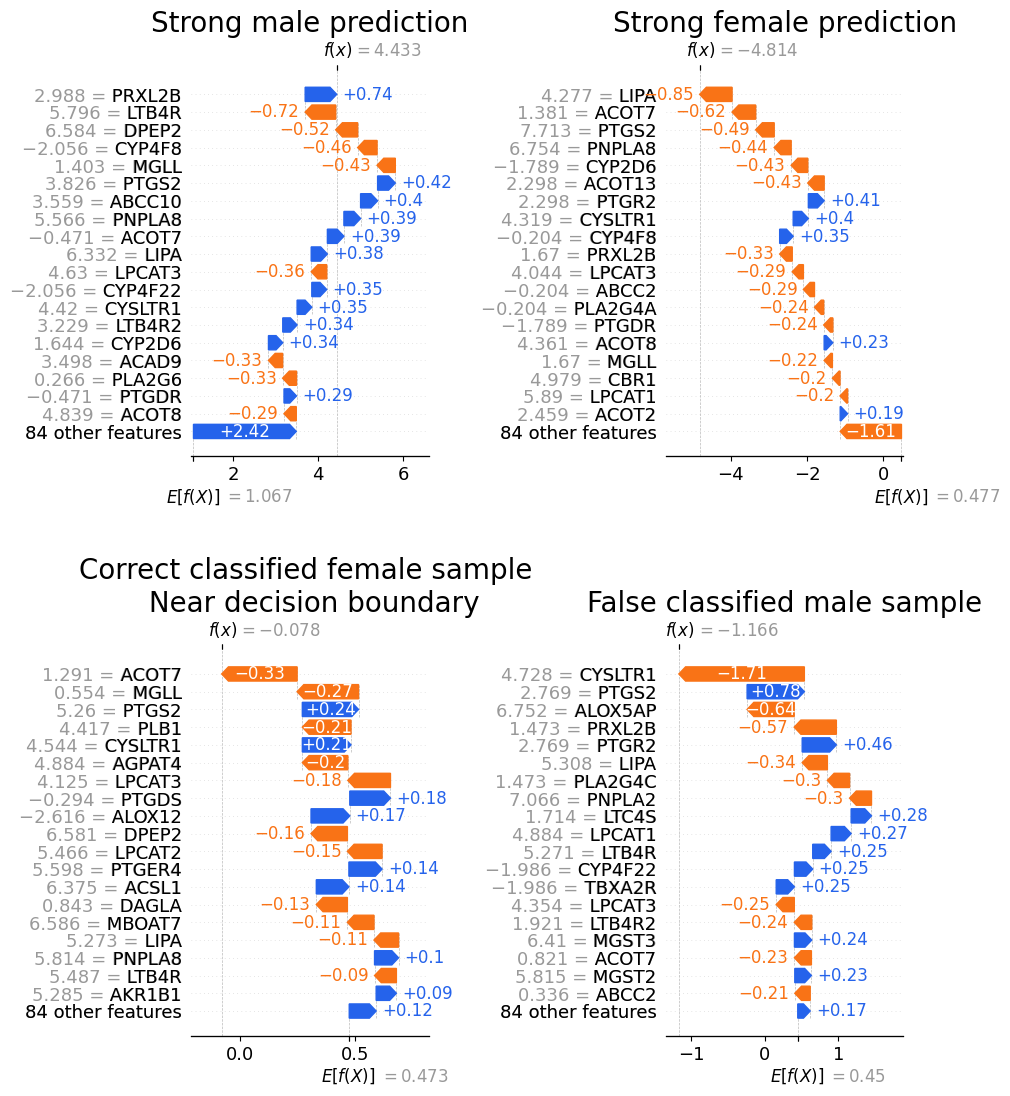

In [19]:
stacked_preds = np.hstack(all_y_pred)
stacked_trues = np.hstack(all_y_true)
stacked_probas = np.hstack(all_probas)

idx_high = np.argmax(stacked_probas)
idx_low = np.argsort(stacked_probas)[4]
log_odds = expected_values + np.sum(shap_all, axis=1)
idx_median = np.where(abs(log_odds) <= 0.1)[0][1]
idx_wrong = np.where(stacked_preds != stacked_trues)[0][0]

fig = plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
shap.plots.waterfall(explanation[idx_high], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong male prediction", fontsize=20)

plt.subplot(2, 2, 2)
shap.plots.waterfall(explanation[idx_low], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong female prediction", fontsize=20)

plt.subplot(2, 2, 3)
shap.plots.waterfall(explanation[idx_median], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Correct classified female sample \n Near decision boundary", fontsize=20)

plt.subplot(2, 2, 4)
shap.plots.waterfall(explanation[idx_wrong], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("False classified male sample", fontsize=20)

plt.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.08, wspace=1, hspace=0.5)
fig.savefig(OUTPUT_FIG / "waterfall.pdf", bbox_inches="tight")
plt.show()

In [19]:
print(stacked_preds[idx_wrong], stacked_trues[idx_wrong])
print(stacked_preds[idx_median], stacked_trues[idx_median])

0 1
0 0
